# Mindestanforderungen 5 - Clustering
- dieses Notebook war lediglich ein Vergleich zum TFIDF-Vectorizer
- wir haben uns für die Cluster des Vectorizers entschieden, weshalb hier keine Beschreibungen im Code vorhanden sind

In [21]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.sparse import hstack, csr_matrix, coo_matrix
from sklearn.cluster import MiniBatchKMeans
from sklearn.decomposition import TruncatedSVD
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from matplotlib.colors import BoundaryNorm

Einlesen des Datensatzes, welcher zuvor im `Cleanup`-Notebook vorbereitet wurde

In [22]:
df = pd.read_csv("One-Hot-Encoded-final.csv")
print("Loaded:", df.shape)

salary_col = "ConvertedCompTotal"
before = df.shape

if salary_col in df.columns:
    df = df.dropna(subset=[salary_col])
    df = df[df[salary_col] > 1000]
    print(f"Dropped salary NaNs ({salary_col}): {before} -> {df.shape}")
else:
    print(f"salary_col '{salary_col}' nicht gefunden – Salary-Filter übersprungen.")

Loaded: (18603, 387)
Dropped salary NaNs (ConvertedCompTotal): (18603, 387) -> (14024, 387)


In [23]:
num_cols_all = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
drop_num = {"ResponseId", "MaxAge", "AgeNum", "RemoteCategoryNum"}
num_cols = [c for c in num_cols_all if c not in drop_num]

X_num_raw = df[num_cols].apply(pd.to_numeric, errors="coerce")

if salary_col in X_num_raw.columns:
    df[f"{salary_col}_raw"] = X_num_raw[salary_col]  # fürs spätere Reporting
    X_num_raw[salary_col] = np.log1p(X_num_raw[salary_col])  # fürs Clustering

num_imputer = SimpleImputer(strategy="median")
num_scaler = StandardScaler()

X_num_imp = num_imputer.fit_transform(X_num_raw)
X_num = num_scaler.fit_transform(X_num_imp)

print("Numeric cols:", len(num_cols))

Numeric cols: 115


In [24]:
dummy_cols = df.select_dtypes(include=["uint8", "bool", "int8"]).columns.tolist()


maybe_binary = []
for c in num_cols:
    if df[c].nunique(dropna=True) <= 2:
        mn = df[c].min(skipna=True)
        mx = df[c].max(skipna=True)
        if pd.notna(mn) and pd.notna(mx) and (mn >= 0) and (mx <= 1):
            maybe_binary.append(c)

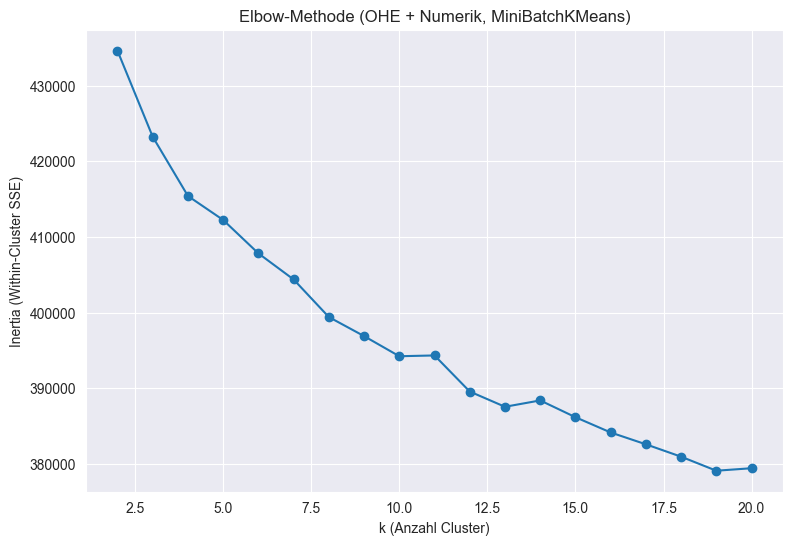

In [25]:
dummy_cols = sorted(set(dummy_cols).union(maybe_binary))
num_cols = [c for c in num_cols if c not in dummy_cols]

X_num_raw = df[num_cols].apply(pd.to_numeric, errors="coerce")
if salary_col in X_num_raw.columns:
    df[f"{salary_col}_raw"] = X_num_raw[salary_col]
    X_num_raw[salary_col] = np.log1p(X_num_raw[salary_col])

X_num_imp = num_imputer.fit_transform(X_num_raw) if len(num_cols) > 0 else np.zeros((len(df), 0))
X_num = num_scaler.fit_transform(X_num_imp) if len(num_cols) > 0 else X_num_imp

def dummies_to_sparse(df_bin: pd.DataFrame) -> csr_matrix:
    n_rows, n_cols = df_bin.shape
    rows_list = []
    cols_list = []

    for j, col in enumerate(df_bin.columns):
        v = df_bin[col].to_numpy()
        nz = np.flatnonzero(v)
        if nz.size:
            rows_list.append(nz)
            cols_list.append(np.full(nz.shape, j, dtype=np.int32))

    if not rows_list:
        return csr_matrix((n_rows, n_cols), dtype=np.float32)

    rows = np.concatenate(rows_list)
    cols = np.concatenate(cols_list)
    data = np.ones(rows.shape[0], dtype=np.float32)

    return coo_matrix((data, (rows, cols)), shape=(n_rows, n_cols)).tocsr()

X_text = dummies_to_sparse(df[dummy_cols]) if len(dummy_cols) > 0 else csr_matrix((len(df), 0))

X_all = hstack([csr_matrix(X_num), X_text]).tocsr()

k_values = list(range(2, 21))
inertias = []

for kk in k_values:
    km_tmp = MiniBatchKMeans(n_clusters=kk, random_state=42, batch_size=2048, n_init=10)
    km_tmp.fit(X_all)
    inertias.append(km_tmp.inertia_)

plt.figure(figsize=(9, 6))
plt.plot(k_values, inertias, marker="o")
plt.xlabel("k (Anzahl Cluster)")
plt.ylabel("Inertia (Within-Cluster SSE)")
plt.title("Elbow-Methode (OHE + Numerik, MiniBatchKMeans)")
plt.grid(True)
plt.show()

In [26]:
k = 13
km = MiniBatchKMeans(n_clusters=k, random_state=42, batch_size=2048, n_init=10)
labels = km.fit_predict(X_all)

In [27]:
df_out = df.copy()
df_out["cluster"] = labels

sizes = df_out["cluster"].value_counts().sort_index()
summary = pd.DataFrame({
    "n": sizes,
    "pct": (sizes / sizes.sum() * 100).round(2)
})
print("\nClustergrößen:")
print(summary)

report_num_cols = num_cols.copy()
if f"{salary_col}_raw" in df_out.columns and salary_col in report_num_cols:
    report_num_cols = [c for c in report_num_cols if c != salary_col] + [f"{salary_col}_raw"]

if len(report_num_cols) > 0:
    print("\nNumerik-Mittelwerte pro Cluster (Original-Skala):")
    print(df_out.groupby("cluster")[report_num_cols].mean().round(2))

centers_scaled_num = km.cluster_centers_[:, :len(num_cols)]
centers_num = num_scaler.inverse_transform(centers_scaled_num) if len(num_cols) > 0 else np.zeros((k, 0))
centers_num = pd.DataFrame(centers_num, columns=num_cols)
centers_num.index.name = "cluster"

if salary_col in centers_num.columns:
    centers_num[salary_col] = np.expm1(centers_num[salary_col])

print("\nCluster-Zentren (Numerik, Original-Skala):")
print(centers_num.round(2))

terms = np.array(dummy_cols)
ignore = np.char.find(terms.astype(str), "_nan") >= 0
centers_text = km.cluster_centers_[:, len(num_cols):]

top_n = 12
print("\nTop OHE-Features pro Cluster (~ Anteil im Cluster):")
for cl in range(km.n_clusters):
    top_idx = np.argsort(centers_text[cl])[::-1][:top_n]
    print(f"\nCluster {cl} (n={int(sizes.get(cl, 0))}):")
    for j in top_idx:
        print(f"  {terms[j]}  ({centers_text[cl][j]:.4f})")

terms = np.array(dummy_cols)
overall = np.asarray(X_text.mean(axis=0)).ravel()

TOP = 12
min_share_cluster = 0.10
min_overall = 0.01

print("\nTop OHE-Enrichment pro Cluster (Lift gegenüber Gesamt):")
for cl in range(km.n_clusters):
    mask = (labels == cl)
    n_cl = int(mask.sum())
    if n_cl == 0:
        continue

    share = np.asarray(X_text[mask].mean(axis=0)).ravel()

    lift = (share + 1e-9) / (overall + 1e-9)
    diff = share - overall

    valid = (share >= min_share_cluster) & (overall >= min_overall) & (~ignore)

    idx = np.argsort(np.where(valid, lift, -np.inf))[::-1][:TOP]

    print(f"\nCluster {cl} (n={n_cl}):")
    for j in idx:
        if not valid[j]:
            continue
        print(f"  {terms[j]} | share={share[j]:.3f} overall={overall[j]:.3f} "
              f"lift={lift[j]:.2f} diff={diff[j]:+.3f}")


Clustergrößen:
            n    pct
cluster             
0         891   6.35
1        1144   8.16
2         972   6.93
3        1196   8.53
4         946   6.75
5         610   4.35
6         988   7.05
7        1088   7.76
8        1511  10.77
9        1220   8.70
10       1232   8.78
11       1182   8.43
12       1044   7.44

Numerik-Mittelwerte pro Cluster (Original-Skala):
         Unnamed: 0  EdLevel  WorkExp  YearsCode  OrgSize  JobSatisfaction  \
cluster                                                                      
0          19009.58     0.78    23.54      29.82     0.70             7.48   
1          25483.03     0.57     4.92       8.08     0.34             6.98   
2          23296.33     0.59    24.35      29.74     0.41             7.57   
3          14955.31     0.65     7.03      11.27     0.41             7.52   
4          19782.62     0.66    10.95      16.11     0.52             3.03   
5          22238.87     0.65    14.92      18.91     0.14             7.

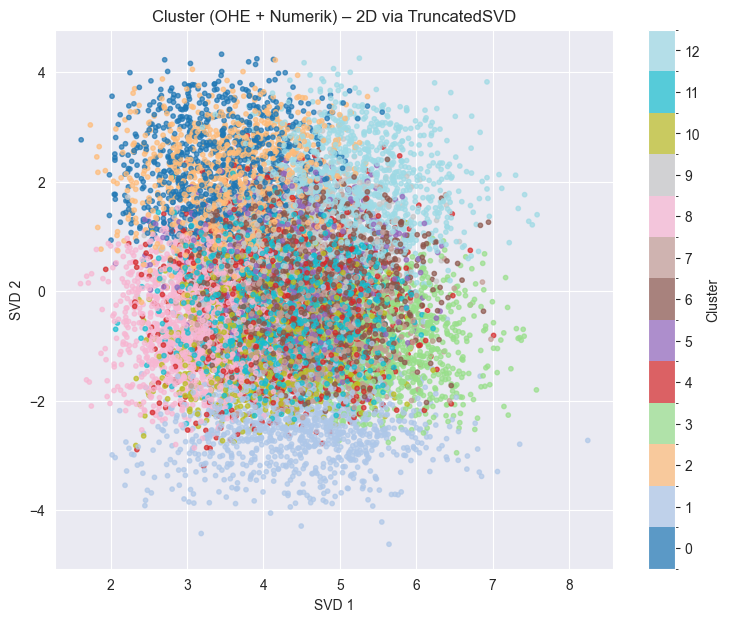

In [28]:
svd = TruncatedSVD(n_components=2, random_state=42)
X_2d = svd.fit_transform(X_all)

k = km.n_clusters
cmap = plt.get_cmap("tab20", k)
norm = BoundaryNorm(np.arange(-0.5, k + 0.5), k)

plt.figure(figsize=(9, 7))
plt.scatter(
    X_2d[:, 0], X_2d[:, 1],
    c=labels,
    cmap=cmap,
    norm=norm,
    s=10,
    alpha=0.7
)
plt.title("Cluster (OHE + Numerik) – 2D via TruncatedSVD")
plt.xlabel("SVD 1")
plt.ylabel("SVD 2")

cbar = plt.colorbar(ticks=range(k))
cbar.set_label("Cluster")

plt.grid(True)
plt.show()